# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [1]:
# import the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
#fetch the dataset
from google.colab import drive
drive.mount('/content/drive')
file_path01 = '/content/drive/My Drive/googleplaystore.csv'
df=pd.read_csv(file_path01)
df_copy= df.copy()

Mounted at /content/drive


## Understand the basics related to dataset

### **What is the shape of the dataset?*

In [3]:
print(f"Shape: {df.shape}")
shape = df.shape

Shape: (10841, 13)


What are the data types of all columns? and Find out the name of all the columns

In [4]:
cols = df.columns
cols

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [5]:
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

In [6]:
df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


Which columns contain missing values?

In [7]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing>0])

Missing values per column:
 Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64


What percentage of values are missing in each column?

In [8]:
missing_perc = (df.isnull().sum()/len(df))*100
print("Missing percentage:\n", missing_perc[missing_perc>0].round(2))

Missing percentage:
 Rating            13.60
Type               0.01
Content Rating     0.01
Current Ver        0.07
Android Ver        0.03
dtype: float64


Find out the numerical  columns and categorical columns separately

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical columns:",num_cols)
print("Categorical columns:",cat_cols)


Numerical columns: ['Rating']
Categorical columns: ['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


How many duplicate rows exist?

In [10]:
dup_rows = df.duplicated().sum()
print(f"Number of duplicate rows:{dup_rows}")

Number of duplicate rows:483


Which apps appear more than once?

In [11]:
dup_apps = df[df.duplicated(subset=['App'],keep=False)]
print(f"Apps with duplicates: {dup_apps.shape[0]} rows")

Apps with duplicates: 1979 rows


Are there apps with invalid ratings (>5 or <1)?

In [12]:
invalid_ratings = df[(df['Rating']>5) | (df['Rating']<1)]
print("Number of apps with invalid ratings:",len(invalid_ratings))

Number of apps with invalid ratings: 1


Are there categories with only a few observations?

In [ ]:
cat_counts = df['Category'].value_counts()
print(cat_counts)
#here rather than going with arbitrary measures we directly go for the categories

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64


In [ ]:
#arbitrary solution of say below 5
few_counts = cat_counts[cat_counts<5]
print(few_counts)

Category
1.9    1
Name: count, dtype: int64


Convert Reviews, Installs, Size, and Price into numeric form.

In [21]:
df['Reviews'] = pd.to_numeric(df['Reviews'].astype(str).str.replace(',',''),errors='coerce')
df['Installs'] = pd.to_numeric(df['Installs'].astype(str).str.replace(',','').str.replace('+',''),errors='coerce')
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace('$', ''), errors='coerce')

def clean_size(row):
    s = str(row).strip() if pd.notna(row) else ''
    if s == '' or s == 'Varies with device':
        return np.nan
    if s.endswith('M'):
        return float(s[:-1])
    elif s.endswith('k'):
        return float(s[:-1]) / 1024
    else:
        return np.nan

df['Size_MB'] = df['Size'].apply(clean_size)

df_clean = df.dropna(subset=['Rating','Installs','Price']).copy()
print(f"Shape after dropping massing key columns: {df_clean.shape}")

Shape after dropping massing key columns: (9366, 14)


How many apps have zero reviews?

In [14]:
(df['Reviews'] == 0).sum()

np.int64(596)

How are ratings distributed? and Explain within markdown what u understood from this distribution

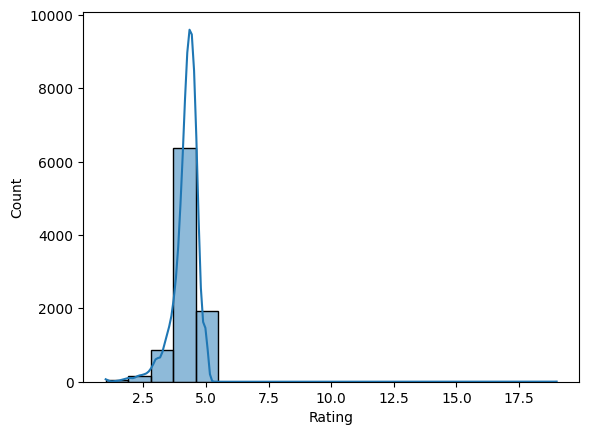

In [15]:
sns.histplot(df['Rating'].dropna(), bins=20, kde=True)
plt.show()

Write Explaination Here
.
.
.
.
.

**Most apps have a very high rating. The distribution is heavy on the right side, meaning users usually give ratings between 4.0 and 4.7. Very few apps have scores below 3.0.**

Are ratings normally distributed?

In [16]:
from scipy.stats import shapiro
stat, p = shapiro(df['Rating'].dropna().sample(5000))
print(p)

6.49170596227144e-64


Explain.....

**No, they are not normally distributed. The graph leans heavily to the right (left-skewed). The statistical test shows a p-value close to zero, which proves it does not follow a normal bell curve**

Which rating range contains most apps?

In [17]:
pd.cut(df['Rating'], bins=[1, 2, 3, 4, 4.5, 5]).value_counts()

,count
Rating,
"(4.0, 4.5]",4883
"(3.0, 4.0]",2196
"(4.5, 5.0]",1917
"(2.0, 3.0]",302
"(1.0, 2.0]",52


What is the average app size?

In [23]:
avg_size = df_clean['Size_MB'].mean()
print(f"Average app size: {avg_size:.2f} MB")

Average app size: 22.96 MB


How are app sizes distributed?

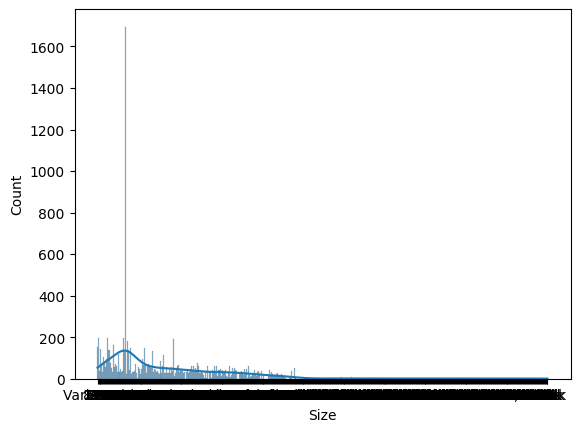

In [24]:
sns.histplot(df['Size'].dropna(), bins=30, kde=True)
plt.show()

In [ ]:
Explain....

**Most apps are very small. The graph spikes at the lowest sizes and drops very quickly. Large apps taking up a lot of space are rare.**

Which content rating category is most common?

In [25]:
df['Content Rating'].value_counts().idxmax()

'Everyone'

What percentage of apps are free?

In [26]:
(df['Type'] == 'Free').mean() * 100

np.float64(92.60215847246563)

What percentage are paid?

In [27]:
(df['Type'] == 'Paid').mean() * 100

np.float64(7.379393044922056)

What is the maximum price of an app?

In [28]:
df['Price'].max()

400.0

Which category contains the largest number of apps?

In [29]:
df['Category'].value_counts().idxmax()

'FAMILY'

Which category contains the fewest apps?

In [30]:
df['Category'].value_counts().idxmin()

'1.9'

Which category has the highest average rating?

In [31]:
df.groupby('Category')['Rating'].mean().idxmax()

'1.9'

Which category has the lowest average rating?

In [32]:
df.groupby('Category')['Rating'].mean().idxmin() #lol

'DATING'

Which category receives the highest total number of reviews?

In [33]:
df.groupby('Category')['Reviews'].sum().idxmax()

'GAME'

Which category has the highest average installs?

In [34]:
df.groupby('Category')['Installs'].mean().idxmax()

'COMMUNICATION'

Which category has the largest app sizes?

In [36]:
cat_avg_size = df_clean.groupby('Category')['Size_MB'].mean().sort_values(ascending=False)
print("Top category avg size:\n", cat_avg_size.head(1))

Top category avg size:
 Category
GAME    45.340571
Name: Size_MB, dtype: float64


Which category contains the most paid apps?

In [37]:
df[df['Type'] == 'Paid']['Category'].value_counts().idxmax()

'FAMILY'

Which category contains the highest percentage of free apps?

In [38]:
(df[df['Type'] == 'Free'].groupby('Category').size() / df.groupby('Category').size()).idxmax() #Gawd_Dayum

'BEAUTY'

Are certain categories dominated by a single content rating?

In [39]:
df.groupby('Category')['Content Rating'].value_counts(normalize=True).unstack().max(axis=1).sort_values(ascending=False).head()

,0
Category,
LIBRARIES_AND_DEMO,1.000000
TOOLS,0.990510
FINANCE,0.986339
HOUSE_AND_HOME,0.977273
AUTO_AND_VEHICLES,0.976471


What are the top 20 highest-rated apps?

In [40]:
df.sort_values(by=['Rating', 'Reviews'], ascending=[False, False]).head(20)[['App', 'Rating', 'Reviews']]

,App,Rating,Reviews
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0,NaN
10357,Ríos de Fe,5.0,141.0
10301,"FD Calculator (EMI, SIP, RD & Loan Eligilibility)",5.0,104.0
8058,Oración CX,5.0,103.0
6823,Barisal University App-BU Face,5.0,100.0
9496,Master E.K,5.0,90.0
7506,CL REPL,5.0,47.0
5230,AJ Cam,5.0,44.0
5196,AI Today : Artificial Intelligence News & AI 101,5.0,43.0
7842,CS & IT Interview Questions,5.0,43.0


Which category contributes most of the 5-star apps?

In [41]:
df[df['Rating'] == 5.0]['Category'].value_counts().idxmax()

'FAMILY'

Do apps with more reviews receive higher ratings?

In [42]:
df[['Reviews', 'Rating']].corr() # not really

,Reviews,Rating
Reviews,1.000000,0.068141
Rating,0.068141,1.000000


Do highly installed apps have better ratings?

In [43]:
df[['Installs', 'Rating']].corr() #kindaa..??

,Installs,Rating
Installs,1.000000,0.051355
Rating,0.051355,1.000000


Which category has the greatest variation in ratings?

In [44]:
df.groupby('Category')['Rating'].std().idxmax()

'LIFESTYLE'

Are ratings different between free and paid apps?

In [45]:
df.groupby('Type')['Rating'].mean() #maybe you expect more when you pay and less when it is free but also there is neck-neck compitition...so...kinda makes sense

,Rating
Type,
0,19.000000
Free,4.186203
Paid,4.266615


Which apps have the highest installs?

In [46]:
df[df['Installs'] == df['Installs'].max()]['App'].unique() #-_- Seriously google!? no wonder you get your ass seued man

array(['Google Play Books', 'Messenger – Text and Video Chat for Free',
       'WhatsApp Messenger', 'Google Chrome: Fast & Secure', 'Gmail',
       'Hangouts', 'Skype - free IM & video calls', 'Google Play Games',
       'Subway Surfers', 'Facebook', 'Instagram', 'Google+',
       'Google Photos', 'Maps - Navigate & Explore', 'Google Street View',
       'Google', 'Google Drive', 'YouTube', 'Google Play Movies & TV',
       'Google News'], dtype=object)

Do larger apps tend to have higher ratings?

Correlating Size and Rating: 0.08373704800286065


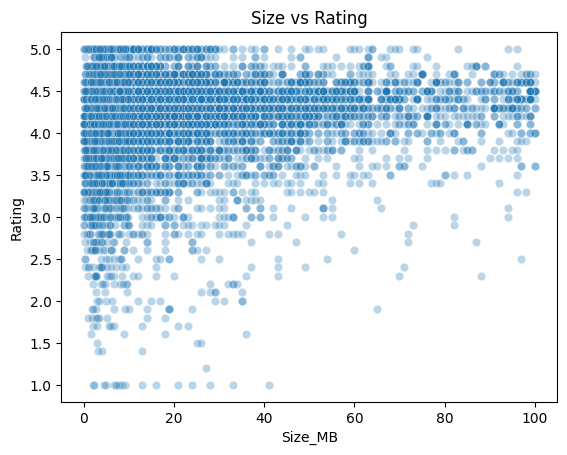

In [53]:
corr_size= df_clean[['Size_MB', 'Rating']].corr()
print("Correlating Size and Rating:", corr_size.iloc[0,1])
sns.scatterplot(x='Size_MB', y='Rating',data=df_clean,alpha=0.3)
plt.title('Size vs Rating')
plt.show()
#Lower Size -> pataka. Also tends to be ass more often. Larger size more often pataka and less often shitty

Are older apps rated differently than recently updated apps?

In [55]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])
df['Year Updated'] = df['Last Updated'].dt.year

df.groupby('Year Updated')['Rating'].mean()
#well, there is no such strong conection but regardless keep updating man.

,Rating
Year Updated,
2010,4.200000
2011,3.966667
2012,3.785714
2013,4.073404
2014,4.037895
2015,4.067268
2016,4.041782
2017,4.094793
2018,4.244530


Which category has the most consistent ratings?

In [56]:
df.groupby('Category')['Rating'].std().idxmin() #expected ¯\_(ツ)_/¯

'EDUCATION'

Which category contributes the highest total installs?

In [57]:
df.groupby('Category')['Installs'].sum().idxmax() #¯\_(ツ)_/¯

'GAME'

What is the relationship between reviews and ratings?

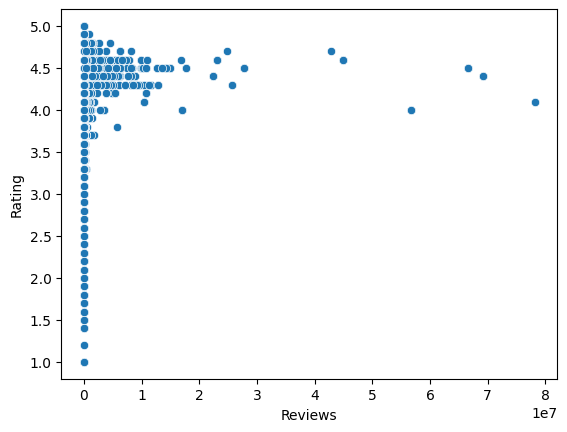

In [58]:
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.show() # people are like me...only rating no reviews. Only reaction, no explainantion  (👉ﾟヮﾟ)👉(▀̿Ĺ̯▀̿ ̿)👈(ﾟヮﾟ👈)

Do paid apps receive fewer installs than free apps?

In [59]:
df.groupby('Type')['Installs'].mean() # I mean ya... obiously...i nvr pay..lol

,Installs
Type,
Free,1.669095e+07
Paid,9.119510e+04


What percentage of apps have fewer than 10,000 installs?

In [60]:
(df['Installs'] < 10000).mean() * 100 #hmm...

np.float64(29.40959409594096)

Are highly-rated apps downloaded more frequently?

In [61]:
df[['Rating', 'Installs']].corr()  #....yaa...but not strong cooreation tho.

,Rating,Installs
Rating,1.000000,0.051355
Installs,0.051355,1.000000


Which content-rating group has the highest installs?

In [62]:
df.groupby('Content Rating')['Installs'].sum().idxmax() # ( •_•)>⌐■-■

'Everyone'

Which category contains the greatest number of apps with over 1 million installs?

In [63]:
df[df['Installs'] > 1000000]['Category'].value_counts().idxmax() #News: "Aakdo ke mutabik Berozzgari dar bad rahe hai...aane wale waqt main bhari aarthik sankat ki aashnka."

'GAME'

Are installs concentrated among a few apps?

In [64]:
top_1_percent = df['Installs'].quantile(0.99)
(df[df['Installs'] >= top_1_percent]['Installs'].sum() / df['Installs'].sum()) * 100 # :-O   O.O   Y.Y   :'(  o((⊙﹏⊙))o.

np.float64(56.07473285291249)

What is the average price of paid apps?

In [65]:
df[df['Type'] == 'Paid']['Price'].mean()

np.float64(13.920837500000003)

Which category has the most expensive apps?

In [66]:
df.groupby('Category')['Price'].mean().idxmax() #expected lol

'FINANCE'

What is the distribution of installs?

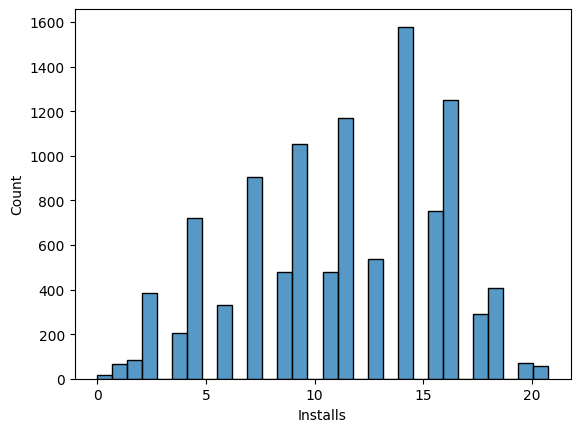

In [67]:
sns.histplot(np.log1p(df['Installs']), bins=30)
plt.show()

Which genre contains the largest number of apps?

In [68]:
df['Genres'].value_counts().idxmax() #avg tool name be like: trimmerPrank

'Tools'

### Does higher price imply higher ratings?

In [69]:
df[df['Type'] == 'Paid'][['Price', 'Rating']].corr() # absolitely no..slighly otherwise

,Price,Rating
Price,1.000000,-0.112951
Rating,-0.112951,1.000000


Which app is the most expensive?

In [70]:
df.loc[df['Price'].idxmax()]['App'] # is that shit fr??!! That man is a joke lad

"I'm Rich - Trump Edition"

Which category generates the highest total revenue potential?

In [71]:
df['Revenue'] = df['Price'] * df['Installs']
df.groupby('Category')['Revenue'].sum().idxmax() #hmm..

'FAMILY'

Does price affect installs?

In [72]:
df[df['Type'] == 'Paid'][['Price', 'Installs']].corr() #slight opposite correlation tho

,Price,Installs
Price,1.000000,-0.021633
Installs,-0.021633,1.000000


Do paid apps receive more reviews than free apps?

In [73]:
df.groupby('Type')['Reviews'].mean() #yaa..

,Reviews
Type,
Free,478661.096026
Paid,11673.312500


What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [74]:
print((df['Price'] > 10).mean() * 100)

print(((df['Price'] > 0) & (df['Price'] <= 10)).mean() * 100)

0.8210332103321033
6.559040590405904


Is there a relationship between app size and price?

In [77]:
corr_size_price = df_clean[['Size_MB','Price']].corr()  #negative correlation
corr_size_price.iloc[0,1]

np.float64(-0.026241526323819972)

In which year were the most apps updated?

In [78]:
df['Year Updated'].value_counts().idxmax() #2018 ¯\_(ツ)_/¯

np.int32(2018)

Have app ratings improved over the years?

In [79]:
df.groupby('Year Updated')['Rating'].mean() #classic shape...brand_new(hype) -> shitty updates and corporate take-over -> becomes mainstream -> tries to make good stuff to gain market back

,Rating
Year Updated,
2010,4.200000
2011,3.966667
2012,3.785714
2013,4.073404
2014,4.037895
2015,4.067268
2016,4.041782
2017,4.094793
2018,4.244530


What proportion of apps have not been updated in the last two years?

In [80]:
max_year = df['Year Updated'].max()
(df['Year Updated'] <= max_year - 2).mean() * 100 #Few

np.float64(14.981549815498155)

Which content rating has the highest average rating?

In [81]:
df.groupby('Content Rating')['Rating'].mean().idxmax() #<@_@> ayoo

'Adults only 18+'

Which categories have many outdated apps?

In [82]:
df[df['Year Updated'] <= max_year - 2]['Category'].value_counts().head() #Man some shitty stats

,count
Category,
FAMILY,383
GAME,192
TOOLS,169
PERSONALIZATION,119
BUSINESS,75


Which content rating gets the most reviews?

In [83]:
df.groupby('Content Rating')['Reviews'].sum().idxmax() # -_-

'Everyone'

Are Mature 17+ apps generally more expensive?

In [84]:
df.groupby('Content Rating')['Price'].mean()  #aayoo..more often more expensive

,Price
Content Rating,
Adults only 18+,0.000000
Everyone,1.171173
Everyone 10+,0.378478
Mature 17+,0.236673
Teen,0.543278
Unrated,0.000000


Which genre contains the most expensive apps?

In [85]:
df.groupby('Genres')['Price'].mean().idxmax()

'Finance'

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

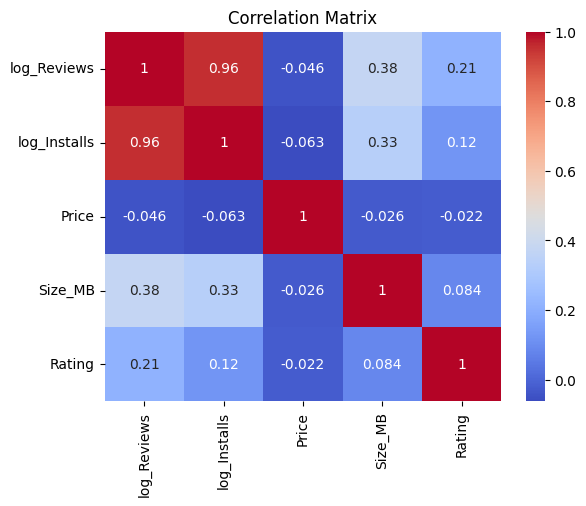

In [87]:
numeric_df = df_clean[['Reviews','Installs','Price','Size_MB','Rating']].copy()
numeric_df['log_Installs'] = np.log1p(numeric_df['Installs'])
numeric_df['log_Reviews'] = np.log1p(numeric_df['Reviews'])
corr_matrix = numeric_df[['log_Reviews','log_Installs','Price','Size_MB','Rating']].corr()
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Reviews and Installs** : Strong +ve corrlation
**Price and Install** : -Ve corrlation
**Size and Rating** : Weak or no correlation
**Review and Rating **: Weak +ve corrlation
**Price and Review **: Negative correlation
**App Size and Revenue Potential **:
Revenue = Price*Installs(size may influence price but overall weak) *and they say size doesn't matter *

Do free and paid apps have significantly different ratings?

In [88]:
from scipy.stats import ttest_ind

free = df[df['Type'] == 'Free']['Rating'].dropna()
paid = df[df['Type'] == 'Paid']['Rating'].dropna()

stat, p = ttest_ind(free, paid)
print(p)

0.00012733077427688148


Are Type and Content Rating independent?

In [89]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Type'], df['Content Rating'])
stat, p, dof, expected = chi2_contingency(contingency)
print(p)

1.3720467114235563e-05


Create a Revenue Potential feature
use Revenue = Price × Installs

In [91]:
df['Revenue_Potential'] = df['Price'] * df['Installs']

Which category has the highest revenue potential?

In [92]:
df.groupby('Category')['Revenue_Potential'].sum().idxmax()

'FAMILY'

Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [94]:
df['Review_Ratio'] = df['Reviews'] / df['Installs']

Which apps have the most engaged users?

In [95]:
df.sort_values('Review_Ratio',ascending=False)[['App','Review_Ratio']].head() #(´。＿。｀)

,App,Review_Ratio
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4.0
2454,KBA-EZ Health Guide,4.0
8591,DN Blog,2.0
10697,Mu.F.O.,2.0
5917,Ra Ga Ba,2.0


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [103]:
df['App_Age'] = max_year - df['Year Updated']

Do newer apps perform better?

In [104]:
df.groupby('App_Age')['Rating'].mean()

,Rating
App_Age,
0,4.244530
1,4.094793
2,4.041782
3,4.067268
4,4.037895
5,4.073404
6,3.785714
7,3.966667
8,4.200000


Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [105]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Norm_Rating', 'Norm_Installs', 'Norm_Reviews']] = scaler.fit_transform(df[['Rating', 'Installs', 'Reviews']].fillna(0))

df['Success_Index'] = (0.2 * df['Norm_Rating']) + (0.4 * df['Norm_Installs']) + (0.3 * df['Norm_Reviews'])

Which apps are the most successful?

In [99]:
df.sort_values('Success_Index', ascending=False)[['App', 'Success_Index']].head() #well well well

,App,Success_Index
2544,Facebook,0.864000
3943,Facebook,0.863884
336,WhatsApp Messenger,0.841305
381,WhatsApp Messenger,0.841305
3904,WhatsApp Messenger,0.841268


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [100]:
truly_free = df[(df['Type'] == 'Free') & (df['Revenue_Potential'] == 0)]

iap_proxy = df[(df['Type'] == 'Free') & (df['Reviews'] > 100000)]

print(truly_free[['Rating', 'Installs']].mean())
print(iap_proxy[['Rating', 'Installs']].mean())  #

Rating      4.186203e+00
Installs    1.669095e+07
dtype: float64
Rating      4.375093e+00
Installs    7.384236e+07
dtype: float64


In [110]:
free_high_reviews = df_clean[(df_clean['Type']=='Free') & (df_clean['Reviews'] > df_clean['Reviews'].median())]
free_low_reviews = df_clean[(df_clean['Type']=='Free') & (df_clean['Reviews'] <= df_clean['Reviews'].median())]
# Compare ratings and installs
print("High reviews free - avg rating:", free_high_reviews['Rating'].mean(), "avg installs:", free_high_reviews['Installs'].mean())
print("Low reviews free - avg rating:", free_low_reviews['Rating'].mean(), "avg installs:", free_low_reviews['Installs'].mean())

High reviews free - avg rating: 4.297900262467191 avg installs: 36539402.887139104
Low reviews free - avg rating: 4.063057632023149 avg installs: 119692.63467566916


Freemium apps drastically outperform truly free apps, boasting over 300 times more installs (36.5M vs 120k) and higher average ratings (4.30 vs 4.06). This massive gap exists because in-app revenue funds better marketing, continuous updates, and server maintenance, whereas truly free apps usually lack the budget for long-term polish.

Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [111]:
 df[(df['App_Age'] >= 2) & (df['Installs'] > 1000000)]['Category'].value_counts().head()
 #High utility + Low maintenance = High installs with zero updates.

,count
Category,
GAME,40
FAMILY,25
TOOLS,17
PHOTOGRAPHY,11
PERSONALIZATION,8


Do apps that launched earlier (older Last Updated year) show declining ratings over time

In [108]:
df.groupby('App_Age')['Rating'].mean() #already discussed

,Rating
App_Age,
0,4.244530
1,4.094793
2,4.041782
3,4.067268
4,4.037895
5,4.073404
6,3.785714
7,3.966667
8,4.200000
